In [1]:
# --- Cell 1: imports + config ---
%load_ext autoreload
%autoreload 2
import sys, copy, torch, numpy as np
sys.path.append('..')
sys.path.append('../..')

from common.seed import set_seed
from common.io_utils import save_results, load_results
from task4.img_prep.cifar_data import build_known_loaders
from task4.backbones.resnet_cifar import CifarResNet18
from task4.training.train_loop import train_model
from task4.methods.proser import PROSER, mix_different_class_pairs
from task4.evaluations.metrics import extract_outputs, accuracy, macro_f1, per_class_accuracy

set_seed(6304)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_ROOT = '../../datasets'
VANILLA_CKPT = '../../datasets/cache/task4_vanilla.pt'
splits = load_results('../../shared/splits/cifar10_seed6304.json')

CFG = dict(seed=6304, num_classes=10, num_dummy=5, batch_size=128, eval_batch=512,
           num_workers=0, epochs=50, lr=1e-3, momentum=0.9, weight_decay=5e-4,
           schedule='cosine', randaugment=False, amp=False,
           beta=1.0, gamma=0.1, mix_alpha=2.0, mix_point='after layer2',
           lambda_per='batch', init_from='datasets/cache/task4_vanilla.pt',
           mix_updates_bn_stats=False)      
print(device, torch.cuda.get_device_name(0) if device.type == 'cuda' else '')


def load_vanilla():
    m = CifarResNet18(num_classes=10).to(device)
    ck = torch.load(VANILLA_CKPT, map_location=device)
    m.load_state_dict(ck['model'])
    return m, ck

cuda NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
# --- Cell 2: VERIFICATION A ---
eval_loaders = build_known_loaders(DATA_ROOT, splits, batch_size=CFG['batch_size'],
                                   eval_batch=CFG['eval_batch'], num_workers=0,
                                   seed=CFG['seed'], randaugment=False)
m0, ck = load_vanilla()
van = load_results('../results/vanilla.json')
v_acc = accuracy(*[extract_outputs(m0, eval_loaders['val'], device, keep_features=False)[k]
                   for k in ('logits', 'labels')])
t_acc = accuracy(*[extract_outputs(m0, eval_loaders['test'], device, keep_features=False)[k]
                   for k in ('logits', 'labels')])
print(f"checkpoint best_epoch     : {ck['best_epoch']}  (expect {van['best_epoch']})")
print(f"reloaded val acc          : {v_acc:.4f}  (expect {van['best_val_acc']:.4f})")
print(f"reloaded test acc         : {t_acc:.4f}  (expect {van['test_accuracy']:.4f})")
del m0; torch.cuda.empty_cache()

checkpoint best_epoch     : 100  (expect 100)
reloaded val acc          : 0.9502  (expect 0.9502)
reloaded test acc         : 0.9461  (expect 0.9461)


In [3]:
# --- Cell 3: VERIFICATION B  ---
dist = torch.distributions.Beta(torch.tensor(2.0), torch.tensor(2.0))
s = dist.sample((100_000,))
print(f"mean  {s.mean():.4f}   (theory 0.5000)")
print(f"std   {s.std():.4f}   (theory 0.2236)")
print(f"P(0.25<=lam<=0.75) {((s >= .25) & (s <= .75)).float().mean():.4f}   (theory 0.6875)")
print(f"P(lam<0.1 or >0.9) {((s < .1) | (s > .9)).float().mean():.4f}   (theory 0.0560)")

mean  0.5005   (theory 0.5000)
std   0.2238   (theory 0.2236)
P(0.25<=lam<=0.75) 0.6862   (theory 0.6875)
P(lam<0.1 or >0.9) 0.0560   (theory 0.0560)


In [4]:
# --- Cell 4: VERIFICATION C — one PROSER step on throwaway copies ---
set_seed(6304)
probe_loaders = build_known_loaders(DATA_ROOT, splits, batch_size=CFG['batch_size'],
                                    eval_batch=CFG['eval_batch'], num_workers=0,
                                    seed=CFG['seed'], randaugment=False)
pm, _ = load_vanilla()
pmeth = PROSER(CFG).to(device)
xb, yb = next(iter(probe_loaders['train']))
xb, yb = xb.to(device), yb.to(device)

n_dummy = sum(p.numel() for p in pmeth.parameters())
print('dummy params            :', n_dummy, '(expect 2565 = 5*512 + 5)')

pm.train(); pmeth.train()
loss, logs = pmeth.compute_loss(pm, xb, yb)
loss.backward()
print({k: round(v, 4) for k, v in logs.items()})
print('grad reaches dummy head :', pmeth.dummy.weight.grad.abs().sum().item() > 0)
print('grad reaches conv1      :', pm.net.conv1.weight.grad.abs().sum().item() > 0)

# masking: only the true slot changes, and it becomes -1e9
with torch.no_grad():
    half = xb.size(0) // 2
    _, fa = pm(xb[:half])
    ext = pmeth.extended_logits(pm, fa)
    masked = ext.masked_fill(torch.nn.functional.one_hot(yb[:half], 11).bool(), -1e9)
    diff = (masked != ext)
    print('ext logits shape        :', tuple(ext.shape), '(expect (64, 11))')
    print('exactly 1 slot masked   :', bool((diff.sum(1) == 1).all()))
    print('masked slot == true y   :', bool((diff.float().argmax(1) == yb[:half]).all()))

    # mixup: every kept pair is different-class; shapes right
    hb = pm.forward_pre(xb[half:])
    h_mix, keep, perm = mix_different_class_pairs(hb, yb[half:], 0.5)
    yb2 = yb[half:]
    print('mixed shape             :', tuple(h_mix.shape), f'(kept {int(keep.sum())}/64)')
    print('all kept pairs differ   :', bool((yb2[keep] != yb2[perm][keep]).all()))

# optimizer really sees the dummy head (the train loop builds params this way)
params = list(pm.parameters()) + list(pmeth.parameters())
print('dummy in optimizer list :', any(p is pmeth.dummy.weight for p in params))
del pm, pmeth, probe_loaders, xb, yb, loss; torch.cuda.empty_cache()

dummy params            : 2565 (expect 2565 = 5*512 + 5)
{'loss': 2.547, 'loss_ce': 0.0026, 'loss_cp': 1.7441, 'loss_dp': 8.0026, 'train_acc': 1.0, 'dummy_runner_up': 0.375, 'dummy_wins_known': 0.0, 'mix_to_dummy': 0.0, 'n_mix': 56.0, 'lam': 0.6568}
grad reaches dummy head : True
grad reaches conv1      : True
ext logits shape        : (64, 11) (expect (64, 11))
exactly 1 slot masked   : True
masked slot == true y   : True
mixed shape             : (50, 128, 16, 16) (kept 50/64)
all kept pairs differ   : True
dummy in optimizer list : True


In [5]:
# --- Cell 4b: VERIFICATION — for blend ---
from task4.methods.proser import bn_stats_frozen
set_seed(6304)
pm, _ = load_vanilla(); pm.train()
x = next(iter(build_known_loaders(DATA_ROOT, splits, batch_size=128, eval_batch=512,
                                  num_workers=0, seed=6304)['train']))[0].to(device)
bn3 = pm.net.layer3[0].bn1
h = pm.forward_pre(x[:64]).detach()
blend = 0.5 * h + 0.5 * h.flip(0)

before = bn3.running_var.clone()
with torch.no_grad(), bn_stats_frozen(pm.net.layer3, pm.net.layer4):
    pm.forward_post(blend)
print('frozen:   running_var unchanged :', torch.equal(before, bn3.running_var))
print('momentum restored afterwards    :', bn3.momentum == 0.1)

with torch.no_grad():
    pm.forward_post(blend)
print('unfrozen: running_var changed   :', not torch.equal(before, bn3.running_var))

print(f'layer2 output variance  clean {h.var().item():.4f} | '
      f'blend {blend.var().item():.4f} | ratio {blend.var().item() / h.var().item():.3f}')
del pm, x, h, blend; torch.cuda.empty_cache()

frozen:   running_var unchanged : True
momentum restored afterwards    : True
unfrozen: running_var changed   : True
layer2 output variance  clean 0.0197 | blend 0.0105 | ratio 0.534


In [6]:
# --- Cell 5: fine-tune PROSER---
set_seed(6304)
loaders = build_known_loaders(DATA_ROOT, splits, batch_size=CFG['batch_size'],
                              eval_batch=CFG['eval_batch'], num_workers=CFG['num_workers'],
                              seed=CFG['seed'], randaugment=CFG['randaugment'])
model, _ = load_vanilla()
method = PROSER(CFG).to(device)          
out = train_model(model, method, loaders, CFG, device,
                  ckpt_path='../../datasets/cache/task4_proser.pt')
print(f"best epoch {out['best_epoch']}  val_acc {out['best_val_acc']:.4f}  {out['minutes']:.1f} min")

ep001 lr=0.0010 loss=0.5162 loss_ce=0.0883 loss_cp=0.1413 loss_dp=2.8647 train_acc=0.9992 dummy_runner_up=0.9743 dummy_wins_known=0.0069 mix_to_dummy=0.0947 n_mix=56.6695 lam=0.5097 | val_acc=0.9484 | best=0.9484@1 | 0.6m
ep002 lr=0.0010 loss=0.3294 loss_ce=0.1032 loss_cp=0.0153 loss_dp=2.1095 train_acc=0.9996 dummy_runner_up=1.0000 dummy_wins_known=0.0080 mix_to_dummy=0.1490 n_mix=56.9886 lam=0.5047 | val_acc=0.9496 | best=0.9496@2 | 1.3m
ep003 lr=0.0010 loss=0.3240 loss_ce=0.1049 loss_cp=0.0127 loss_dp=2.0639 train_acc=0.9993 dummy_runner_up=0.9999 dummy_wins_known=0.0093 mix_to_dummy=0.1546 n_mix=56.7721 lam=0.4868 | val_acc=0.9494 | best=0.9496@2 | 2.0m
ep005 lr=0.0010 loss=0.2901 loss_ce=0.1004 loss_cp=0.0122 loss_dp=1.7747 train_acc=0.9993 dummy_runner_up=0.9998 dummy_wins_known=0.0080 mix_to_dummy=0.2337 n_mix=56.7835 lam=0.5399 | val_acc=0.9482 | best=0.9496@2 | 3.2m
ep010 lr=0.0009 loss=0.0842 loss_ce=0.0336 loss_cp=0.0151 loss_dp=0.3543 train_acc=0.9987 dummy_runner_up=0.9992

In [7]:
# --- Cell 6: freeze and extract---

cache = {}
model.eval(); method.eval()
for split in ['train_eval', 'val', 'test']:
    o = extract_outputs(model, loaders[split], device, keep_features=True)
    with torch.no_grad():
        d = method.dummy(torch.from_numpy(o['features']).to(device)).cpu().numpy()
    cache[f'{split}_logits'] = o['logits']
    cache[f'{split}_features'] = o['features']
    cache[f'{split}_labels'] = o['labels']
    cache[f'{split}_dummy_logits'] = d
    print(f"{split:11s} logits {o['logits'].shape}  dummy {d.shape}")
np.savez_compressed('../../datasets/cache/task4_proser_known.npz', **cache)

csa = accuracy(cache['test_logits'], cache['test_labels'])
van_csa = load_results('../results/vanilla.json')['test_accuracy']
print(f"\nPROSER CSA (10 known logits) : {csa:.4f}")
print(f"Vanilla CSA                  : {van_csa:.4f}   delta {csa - van_csa:+.4f}")

for split in ['val', 'test']:
    z, dd, yy = cache[f'{split}_logits'], cache[f'{split}_dummy_logits'], cache[f'{split}_labels']
    ext = np.concatenate([z, dd.max(1, keepdims=True)], 1)
    wins = (ext.argmax(1) == 10).mean()
    m = ext.copy(); m[np.arange(len(yy)), yy] = -1e9
    ru = (m.argmax(1) == 10).mean()
    print(f"{split:4s}: dummy wins outright {wins:.4f} | dummy is runner-up {ru:.4f}")

pc = per_class_accuracy(cache['test_logits'], cache['test_labels'])
for c, name in enumerate(splits['classes']):
    print(f"  {name:12s} {pc[c]:.4f}")

train_eval  logits (45000, 10)  dummy (45000, 5)
val         logits (5000, 10)  dummy (5000, 5)
test        logits (10000, 10)  dummy (10000, 5)

PROSER CSA (10 known logits) : 0.9438
Vanilla CSA                  : 0.9461   delta -0.0023
val : dummy wins outright 0.0320 | dummy is runner-up 0.9646
test: dummy wins outright 0.0284 | dummy is runner-up 0.9566
  airplane     0.9610
  automobile   0.9740
  bird         0.9190
  cat          0.8850
  deer         0.9540
  dog          0.9010
  frog         0.9770
  horse        0.9480
  ship         0.9570
  truck        0.9620


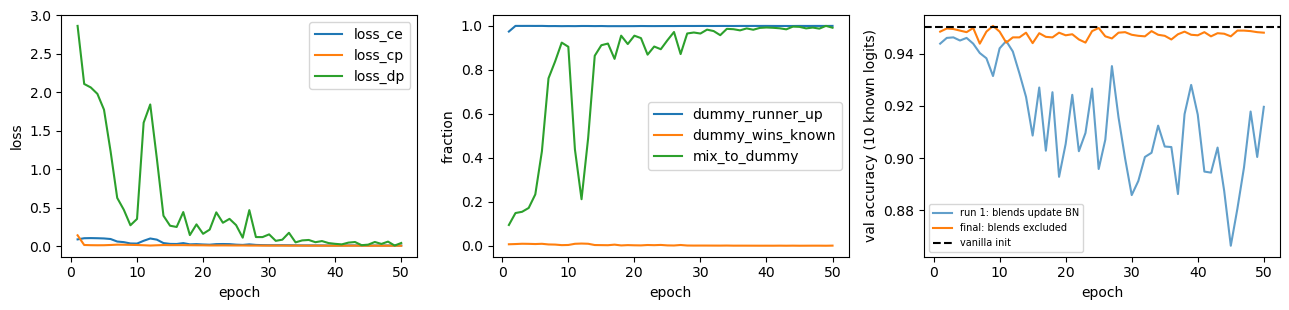

In [9]:
# --- Cell 7: save results + curves ---
results = {'step': 'proser', 'seed': 6304, 'method': 'proser', 'config': CFG,
           'steps_per_epoch': loaders['steps_per_epoch'],
           'best_epoch': out['best_epoch'], 'best_val_acc': out['best_val_acc'],
           'test_accuracy': csa,
           'test_macro_f1': macro_f1(cache['test_logits'], cache['test_labels']),
           'delta_csa_vs_vanilla': csa - van_csa,
           'per_class_test_accuracy': {n: float(pc[i]) for i, n in enumerate(splits['classes'])},
           'minutes': out['minutes'], 'history': out['history'],
           'cache_file': 'datasets/cache/task4_proser_known.npz',
           'counterfactual_run': 'task4/results/proser_run1_bn_mixed.json'}
save_results(results, '../results/proser.json')

import matplotlib.pyplot as plt
h = out['history']; ep = [r['epoch'] for r in h]
run1 = load_results('../results/proser_run1_bn_mixed.json')['history']

fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
for k in ['loss_ce', 'loss_cp', 'loss_dp']:
    ax[0].plot(ep, [r[k] for r in h], label=k)
ax[0].set_xlabel('epoch'); ax[0].set_ylabel('loss'); ax[0].legend()

for k in ['dummy_runner_up', 'dummy_wins_known', 'mix_to_dummy']:
    ax[1].plot(ep, [r[k] for r in h], label=k)
ax[1].set_xlabel('epoch'); ax[1].set_ylabel('fraction'); ax[1].legend()

ax[2].plot([r['epoch'] for r in run1], [r['val_acc'] for r in run1],
           label='run 1: blends update BN', alpha=0.7)
ax[2].plot(ep, [r['val_acc'] for r in h], label='final: blends excluded')
ax[2].axhline(load_results('../results/vanilla.json')['best_val_acc'], ls='--', c='k',
              label='vanilla init')
ax[2].set_xlabel('epoch'); ax[2].set_ylabel('val accuracy (10 known logits)')
ax[2].legend(fontsize=7)

plt.tight_layout(); plt.savefig('../../report/figures/task4_proser_curves.png', dpi=200)
plt.show()